In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, f1_score, precision_score, recall_score, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.metrics import roc_auc_score, balanced_accuracy_score

In [19]:
feature_df = pd.read_csv('feature_data.csv')
operation_df = pd.read_csv('operational_dataset.csv')
feature_df.set_index('Date', inplace=True)
operation_df.set_index('Date', inplace=True)

In [20]:
operation_df['destination'] = operation_df['target']

In [21]:
# Join feature_df and operation_df on Date, source, and destination
merged_df = feature_df.merge(operation_df, on=['Date', 'source', 'destination'], how='inner')

# Display the merged dataframe
merged_df.drop(columns=['target'], axis=1, inplace=True)
feature_df = merged_df

In [22]:
never_disrupted = feature_df[feature_df['Total_disruptions'] == 0]

print("Mean and median of rides planned for never disrupted trajectories:")
print(np.mean(never_disrupted['Total_rides']))
print(np.median(never_disrupted['Total_rides']))
print("Mean and median of rides planned for disrupted trajectories:")
print(np.mean(feature_df[feature_df['Total_disruptions'] > 0]['Total_rides']))
print(np.median(feature_df[feature_df['Total_disruptions'] > 0]['Total_rides']))
print("Percentage of never disrupted trajectories:")
perc = 37637 / 612790 * 100
print(perc)

# Remove never disrupted trajectories
feature_df = feature_df[feature_df['Total_disruptions'] > 0]

Mean and median of rides planned for never disrupted trajectories:
718.5161410314319
54.0
Mean and median of rides planned for disrupted trajectories:
12311.730057915025
4472.0
Percentage of never disrupted trajectories:
6.14190832095824


In [38]:
topo_features = [ 
    'source_degree', 'source_weighted_degree', 'source_avg_distance', 
    'target_degree', 'target_weighted_degree', 'target_avg_distance', 
    'common_neighbors', 'jaccard_coefficient', 'preferential_attachment', 
    'adamic_adar_index', 'resource_allocation_index','weight', 'distance']
wthr_features = ['FHVEC', 'TG', 'TN', 'TX', 'T10N', 'SQ', 'RH', 'RHX', 'VVX']
oper_features = ['Days_since_last_disruption','Num_prev_disruptions', 'Ratio', 
                'Total_disruptions', 'Total_rides'
                #, 'Previous_causes_vec', 'Most_recent_causes_vec' (still need to solve vector inputs)
                ]   
X_topo = np.array(feature_df[topo_features])
X_wthr = np.array(feature_df[wthr_features])
X_oper = np.array(feature_df[oper_features])
X_comp = np.array(feature_df.drop(columns=['source', 'destination', 'Disrupted', 'Previous_causes_vec', 'Most_recent_causes_vec']))
y = np.array(feature_df['Disrupted'])

In [34]:
feature_df

,source,destination,source_degree,source_weighted_degree,source_avg_distance,target_degree,target_weighted_degree,target_avg_distance,common_neighbors,jaccard_coefficient,...,T10N,FHVEC,Disrupted,Days_since_last_disruption,Num_prev_disruptions,Ratio,Total_disruptions,Total_rides,Previous_causes_vec,Most_recent_causes_vec
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-01,'s-Hertogenbosch,Roosendaal,14,83,31.714286,13,52,39.230769,2,0.142857,...,28.0,40.0,True,0,0,0.000000,1,2,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...
2019-01-01,'s-Hertogenbosch,Utrecht Centraal,14,83,31.714286,36,243,21.305556,2,0.071429,...,28.0,40.0,True,0,0,0.000000,2,1,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. ...
2019-01-01,Den Haag Centraal,Eindhoven Centraal,29,253,52.793103,21,116,40.142857,3,0.111111,...,50.0,52.0,True,0,0,0.000000,1,32,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...
2019-01-01,Den Haag Centraal,Utrecht Centraal,29,253,52.793103,36,243,21.305556,10,0.333333,...,50.0,52.0,True,0,0,0.000000,1,21,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...
2019-01-01,Eindhoven Centraal,Den Haag Centraal,21,116,40.142857,29,253,52.793103,3,0.111111,...,28.0,40.0,True,0,0,0.000000,1,32,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,Zwolle,Lelystad Centrum,23,104,53.608696,15,78,59.133333,4,0.235294,...,29.0,82.0,False,16,41,0.807882,41,5075,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...
2024-12-31,Zwolle,Nijmegen,23,104,53.608696,19,64,56.000000,7,0.411765,...,29.0,82.0,False,34,29,0.975774,29,2972,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...
2024-12-31,Zwolle,Roosendaal,23,104,53.608696,18,83,53.277778,4,0.222222,...,29.0,82.0,False,9,380,0.595229,380,63841,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...


In [25]:
from sklearn.model_selection import TimeSeriesSplit

tss = TimeSeriesSplit(n_splits = 12)

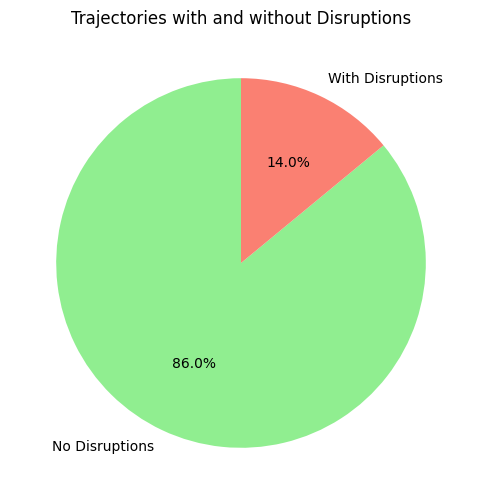

In [26]:
disrupted = (feature_df["Disrupted"] == True).sum()
non_disrupted =  (feature_df["Disrupted"] == False).sum()

# Data for the pie chart
labels = ['No Disruptions', 'With Disruptions']
sizes = [non_disrupted, disrupted]
colors = ['lightgreen', 'salmon']

# Plot the pie chart
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Trajectories with and without Disruptions')
plt.show()

In [7]:
# One-hot encode source and destination
source_encoded = pd.get_dummies(feature_df['source'], prefix='source')
destination_encoded = pd.get_dummies(feature_df['destination'], prefix='dest')

# Concatenate encoded columns with feature_df
feature_df_encoded = pd.concat([feature_df, source_encoded, destination_encoded], axis=1)

# Optionally drop original source and destination columns
feature_df_encoded = feature_df_encoded.drop(columns=['source', 'destination'])
feature_df_encoded

,source_degree,source_weighted_degree,source_avg_distance,target_degree,target_weighted_degree,target_avg_distance,common_neighbors,jaccard_coefficient,preferential_attachment,adamic_adar_index,...,dest_Zetten-Andelst,dest_Zevenaar,dest_Zevenbergen,dest_Zoetermeer,dest_Zoetermeer Oost,dest_Zuidbroek,dest_Zuidhorn,dest_Zutphen,dest_Zwijndrecht,dest_Zwolle
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-01,14,83,31.714286,14,65,33.714286,3,0.230769,196,1.370312,...,False,False,False,False,False,False,False,False,False,False
2019-01-01,14,83,31.714286,29,253,52.793103,3,0.130435,406,1.181065,...,False,False,False,False,False,False,False,False,False,False
2019-01-01,14,83,31.714286,3,17,18.000000,1,0.111111,42,0.402430,...,False,False,False,False,False,False,False,False,False,False
2019-01-01,14,83,31.714286,18,116,36.555556,4,0.307692,252,1.742067,...,False,False,False,False,False,False,False,False,False,False
2019-01-01,14,83,31.714286,21,116,40.142857,2,0.111111,294,1.788671,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,23,104,53.608696,19,64,56.000000,7,0.411765,437,2.865774,...,False,False,False,False,False,False,False,False,False,False
2024-12-31,23,104,53.608696,18,83,53.277778,4,0.222222,414,1.773758,...,False,False,False,False,False,False,False,False,False,False
2024-12-31,23,104,53.608696,17,34,55.764706,6,0.375000,391,2.690635,...,False,False,False,False,False,False,False,False,False,False


In [8]:
# Define feature columns
feature_columns = [col for col in feature_df_encoded.columns 
                   if col.startswith('source_') or col.startswith('dest_') or 
                   col in topo_features]

# Ensure numeric features
feature_df_encoded[feature_columns] = feature_df_encoded[feature_columns].apply(pd.to_numeric, errors='coerce')

# Define features (X) and target (y)
X_enc = feature_df_encoded[feature_columns]
y_enc = feature_df_encoded['Disrupted'].astype(int)  # Convert True/False to 1/0

In [9]:
param_grid_xgb = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],      
    'n_estimators': [100, 200, 300],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [1, sum(y == 0) / sum(y == 1)]
}

# Define scoring metrics
scoring = {
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

xgb = XGBClassifier(objective='binary:logistic', eval_metric='auc', random_state=42)

In [10]:
param_grid_rf = {
        'n_estimators': [100, 200, 500, 1000],
        'max_features': ['auto', 'sqrt', 'log2'],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'bootstrap': [True, False]
    }
rf = RandomForestClassifier(random_state=42)
param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'min_samples_split': [2, 5, 10]
}
gb = GradientBoostingClassifier(random_state=42)

In [11]:
param_grid_lg = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2', 'elasticnet'],
        'solver': ['liblinear', 'saga', 'newton-cg'],
    }
logres = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')

In [12]:
from xgboost import plot_importance
import shap

def plot_feature_importance(model, feature_names, max_num_features=20, model_type=None):
    """
    Plot feature importance for different model types.
    """
    if model_type == 'xgboost':
        plot_importance(model, max_num_features=max_num_features)
        plt.title("XGBoost Feature Importance")
        return
    elif model_type == 'logistic':
        importance = np.abs(model.coef_[0])
        importance_label = "Absolute Coefficient"
    elif model_type in ['random_forest', 'gradient_boosting']:
        importance = model.feature_importances_
        importance_label = "Feature Importance (Gini/Impurity Reduction)"
    else:
        raise ValueError("Unsupported model type. Use 'xgboost', 'logistic', 'random_forest', or 'gradient_boosting'.")

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    })
    importance_df = importance_df.sort_values(by='Importance', ascending=False).head(max_num_features)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.xlabel(importance_label)
    plt.ylabel("Feature")
    plt.title(f"{model_type.replace('_', ' ').title()} Feature Importance")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


def plot_shap_values(model, X_test, feature_names, model_type=None):
    """
    Plot SHAP values for tree-based models.
    
    Parameters:
    - model: Trained tree-based model (RandomForestClassifier, GradientBoostingClassifier, XGBClassifier)
    - X_test: Test feature matrix (pandas DataFrame or numpy array)
    - feature_names: List of feature names
    - model_type: String indicating model type ('random_forest', 'gradient_boosting', 'xgboost')
    """
    if model_type not in ['random_forest', 'gradient_boosting', 'xgboost']:
        print(f"SHAP plotting is only supported for tree-based models, not '{model_type}'.")
        return
    
    # Convert X_test to DataFrame if it's a numpy array to ensure feature names are used
    if not isinstance(X_test, pd.DataFrame):
        X_test = pd.DataFrame(X_test, columns=feature_names)
    
    # Initialize SHAP TreeExplainer
    explainer = shap.TreeExplainer(model)
    
    # Compute SHAP values
    shap_values = explainer.shap_values(X_test)
    
    # For binary classification, shap_values may be a list (for XGBoost) or array
    # We typically want the SHAP values for the positive class (index 1 for binary classification)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # Positive class for XGBoost
    
    # Plot SHAP summary plot
    plt.figure()
    shap.summary_plot(shap_values, X_test, feature_names=feature_names, max_display=20, show=False)
    plt.title(f"SHAP Summary Plot for {model_type.replace('_', ' ').title()}")
    plt.tight_layout()
    plt.show()


def optimise(model, scoring, param_grid, X, y):
    """
    Optimize a model using RandomizedSearchCV with time-series cross-validation,
    plot feature importance, and plot SHAP values for tree-based models.
    
    Parameters:
    - model: Model to optimize (e.g., XGBClassifier, LogisticRegression, etc.)
    - scoring: Scoring metric(s) for RandomizedSearchCV
    - param_grid: Parameter grid for RandomizedSearchCV
    - X: Feature matrix (pandas DataFrame or numpy array)
    - y: Target vector
    """
    test_size = 0.2
    n_samples = len(X)
    train_size = int((1 - test_size) * n_samples)
    
    X_train = X[:train_size]
    X_test = X[train_size:]
    y_train = y[:train_size]
    y_test = y[train_size:]
    
    # Time-series cross-validation
    tscv = TimeSeriesSplit(n_splits=6)
    
    # Randomized search with time-series CV
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=10,
        scoring=scoring,
        refit='f1',
        cv=tscv,
        verbose=1,
        n_jobs=-1,
        random_state=42
    )
    
    # Fit the model
    random_search.fit(X_train, y_train)
    
    # Results
    print("Best Parameters:", random_search.best_params_)
    print("Best F1 Score:", random_search.best_score_)
    
    # Evaluate best model
    best_model = random_search.best_estimator_
    y_pred = best_model.predict(X_test)
    print("Test Set Classification Report:")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")
    print(f"AUC: {roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1]):.4f}")
    
    # Determine model type for feature importance and SHAP plotting
    if isinstance(best_model, XGBClassifier):
        model_type = 'xgboost'
    elif isinstance(best_model, LogisticRegression):
        model_type = 'logistic'
    elif isinstance(best_model, RandomForestClassifier):
        model_type = 'random_forest'
    elif isinstance(best_model, GradientBoostingClassifier):
        model_type = 'gradient_boosting'
    
    # Get feature names
    if isinstance(X, pd.DataFrame):
        feature_names = X.columns
    else:
        feature_names = [f"Feature_{i}" for i in range(X.shape[1])]
    
    # Plot feature importance
    plot_feature_importance(best_model, feature_names, max_num_features=20, model_type=model_type)
    
    # Plot SHAP values for tree-based models
    if model_type != 'Logistic':
        plot_shap_values(best_model, X_test, feature_names, model_type=model_type)
    
    return best_model

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fitting 6 folds for each of 10 candidates, totalling 60 fits
Best Parameters: {'subsample': 1.0, 'scale_pos_weight': 6.600401855480862, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best F1 Score: 0.4057400093846459
Test Set Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.73      0.82    108658
        True       0.25      0.72      0.37     13900

    accuracy                           0.72    122558
   macro avg       0.60      0.72      0.60    122558
weighted avg       0.87      0.72      0.77    122558

Accuracy: 0.7247
F1 Score: 0.3712
Precision: 0.2505
Recall: 0.7164
Balanced Accuracy: 0.7211
AUC: 0.7966


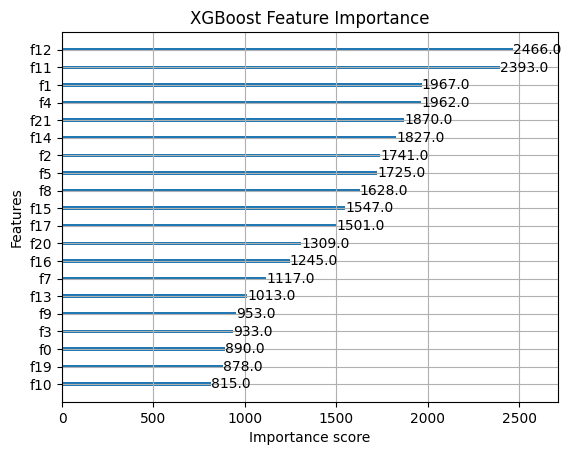

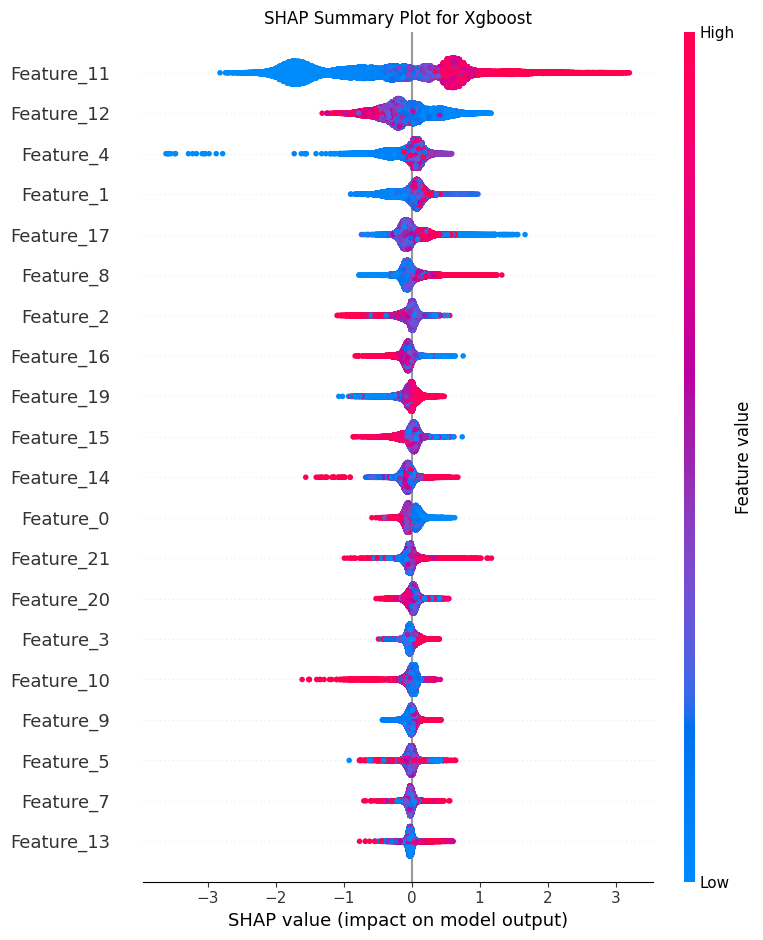

In [13]:
xgb_model = optimise(xgb, scoring, param_grid_xgb, X_comp, y)

Fitting 6 folds for each of 10 candidates, totalling 60 fits


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py:542: FitFailedWarning: 
6 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py", line 890, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 1344, in wrapper
    estimator._validate_params()
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraint

Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30, 'bootstrap': False}
Best F1 Score: 0.2246271503651047
Test Set Classification Report:
              precision    recall  f1-score   support

       False       0.90      0.98      0.94    108658
        True       0.47      0.16      0.24     13900

    accuracy                           0.88    122558
   macro avg       0.68      0.57      0.59    122558
weighted avg       0.85      0.88      0.86    122558

Accuracy: 0.8841
F1 Score: 0.2369
Precision: 0.4677
Recall: 0.1586
Balanced Accuracy: 0.5678
AUC: 0.7885


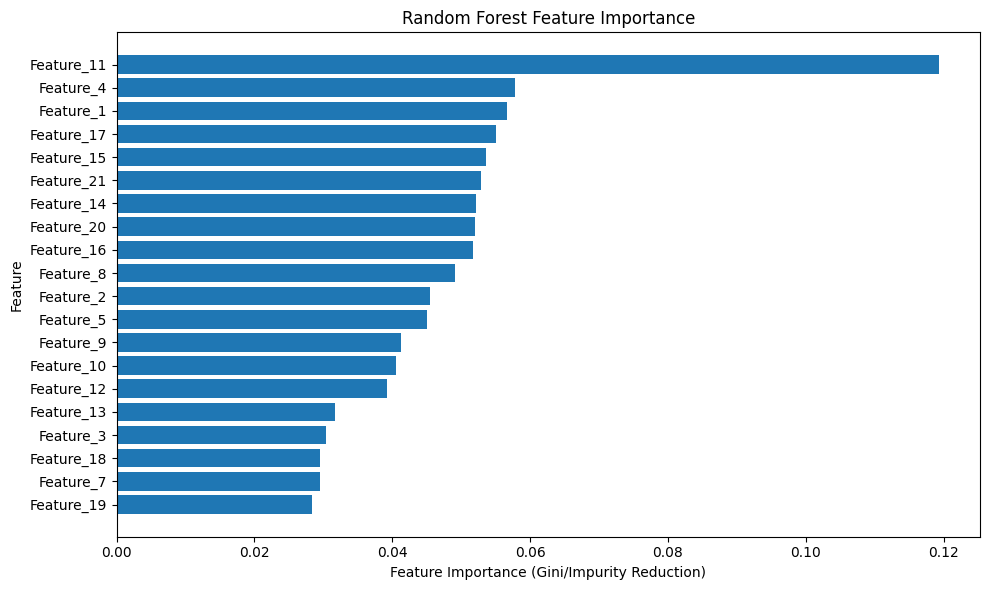

In [ ]:
rf_model = optimise(rf, scoring, param_grid_rf, X_comp, y)

In [ ]:
gb_model = optimise(gb, scoring, param_grid_gb, X_comp, y)

Fitting 6 folds for each of 10 candidates, totalling 60 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 7, 'learning_rate': 0.3}
Best F1 Score: 0.26999984440888675
Test Set Classification Report:
              precision    recall  f1-score   support

       False       0.90      0.95      0.93    108658
        True       0.36      0.21      0.27     13900

    accuracy                           0.87    122558
   macro avg       0.63      0.58      0.60    122558
weighted avg       0.84      0.87      0.85    122558

Accuracy: 0.8684
F1 Score: 0.2690
Precision: 0.3635
Recall: 0.2135
Balanced Accuracy: 0.5829
AUC: 0.7792


ValueError: tree must be Booster, XGBModel or dict instance

Fitting 6 folds for each of 10 candidates, totalling 60 fits


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py:542: FitFailedWarning: 
18 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
12 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py", line 890, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 1351, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\line

Best Parameters: {'solver': 'newton-cg', 'penalty': 'l2', 'C': 1}
Best F1 Score: 0.38128393548616124
Test Set Classification Report:
              precision    recall  f1-score   support

       False       0.94      0.76      0.84    108658
        True       0.24      0.60      0.34     13900

    accuracy                           0.74    122558
   macro avg       0.59      0.68      0.59    122558
weighted avg       0.86      0.74      0.78    122558

Accuracy: 0.7411
F1 Score: 0.3439
Precision: 0.2413
Recall: 0.5982
Balanced Accuracy: 0.6788
AUC: 0.7477


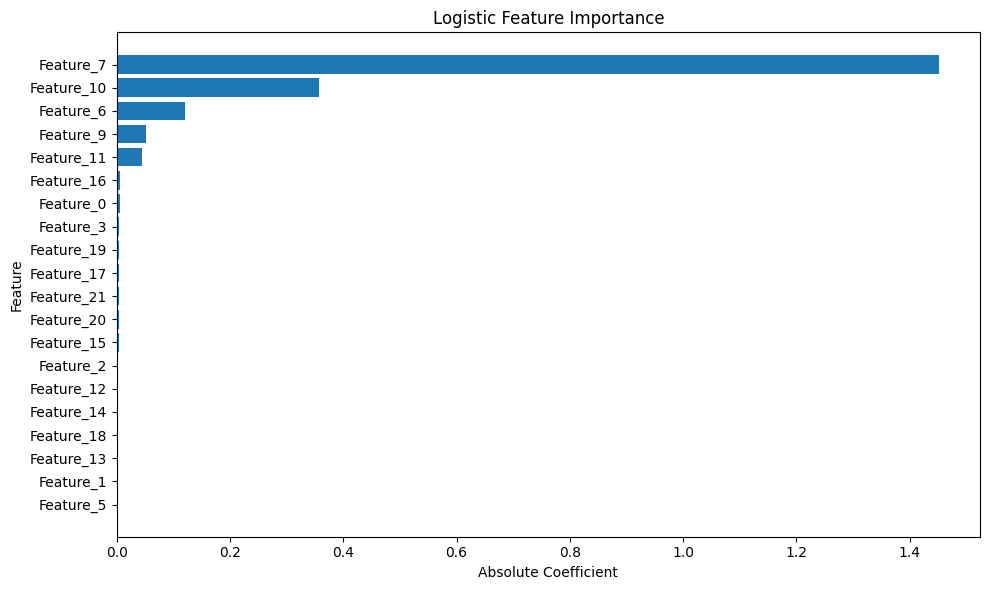

SHAP plotting is only supported for tree-based models, not 'logistic'.


In [14]:
logres_model = optimise(logres, scoring, param_grid_lg, X_comp, y)

In [35]:
best_parameters_lr = {'solver': 'newton-cg', 'penalty': 'l2', 'C': 1}
best_parameters_xgb = {'subsample': 1.0, 'scale_pos_weight': 6.600401855480862, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
best_parameters_rf = {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30, 'bootstrap': False}
best_parameters_gb = {'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 7, 'learning_rate': 0.3}

In [39]:
def compare_models(X, y, resample=True, n_splits=6):
    scaler = StandardScaler()
    tss = TimeSeriesSplit(n_splits=n_splits)
    
    # Initialize classifiers
    logres = LogisticRegression(random_state=42, class_weight='balanced')
    rf = RandomForestClassifier(random_state=42, class_weight='balanced', **best_parameters_rf)
    xgb = XGBClassifier(random_state=42, **best_parameters_xgb)
    gbdt = GradientBoostingClassifier(random_state=42, **best_parameters_gb)
    classifiers = [logres, rf, xgb, gbdt]
    
    # Store metrics for each model and fold
    model_metrics = {
        clf.__class__.__name__: {'balanced_acc': [], 'f1': [], 'auc': []} 
        for clf in classifiers
    }
    
    # Split the data into train and test sets
    for fold, (train_index, test_index) in enumerate(tss.split(X), 1):
        print(f"\nFold {fold}/{n_splits}")
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        # Apply SMOTE to training set if resample=True
        if resample:
            smote = SMOTE(random_state=42)
            X_train, y_train = smote.fit_resample(X_train, y_train)
        
        # Scale the features
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Update scale_pos_weight for XGBClassifier based on training data
        if sum(y_train == 1) > 0:  # Avoid division by zero
            xgb.set_params(scale_pos_weight=sum(y_train == 0) / sum(y_train == 1))
        
        # Train and evaluate each classifier
        for classifier in classifiers:
            # Fit the classifier
            classifier.fit(X_train_scaled, y_train)
            
            # Predict on the test set
            y_test_pred = classifier.predict(X_test_scaled)
            y_test_proba = classifier.predict_proba(X_test_scaled)[:, 1] if hasattr(classifier, 'predict_proba') else y_test_pred
            
            # Calculate metrics for this fold
            balanced_acc = balanced_accuracy_score(y_test, y_test_pred)
            f1 = f1_score(y_test, y_test_pred)
            auc = roc_auc_score(y_test, y_test_proba)
            
            # Store metrics
            model_metrics[classifier.__class__.__name__]['balanced_acc'].append(balanced_acc)
            model_metrics[classifier.__class__.__name__]['f1'].append(f1)
            model_metrics[classifier.__class__.__name__]['auc'].append(auc)
    
    # Calculate mean and std of metrics for each model
    rows = []
    for model_name in model_metrics:
        balanced_acc_mean = np.mean(model_metrics[model_name]['balanced_acc'])
        balanced_acc_std = np.std(model_metrics[model_name]['balanced_acc'])
        f1_mean = np.mean(model_metrics[model_name]['f1'])
        f1_std = np.std(model_metrics[model_name]['f1'])
        auc_mean = np.mean(model_metrics[model_name]['auc'])
        auc_std = np.std(model_metrics[model_name]['auc'])
        
        print(f"\nAggregated metrics for {model_name}:")
        print(f"Balanced Accuracy: {balanced_acc_mean:.4f} ± {balanced_acc_std:.4f}")
        print(f"F1 Score: {f1_mean:.4f} ± {f1_std:.4f}")
        print(f"AUC: {auc_mean:.4f} ± {auc_std:.4f}")
        
        # Store metrics
        row = {
            'model': model_name,
            'balanced_acc_mean': balanced_acc_mean,
            'balanced_acc_std': balanced_acc_std,
            'f1_mean': f1_mean,
            'f1_std': f1_std,
            'auc_mean': auc_mean,
            'auc_std': auc_std
        }
        rows.append(row)
    
    return rows

In [40]:
compare_models(X_comp, y, False)


Fold 1/6

Fold 2/6


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Fold 3/6


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Fold 4/6


...

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Fold 6/6


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Aggregated metrics for LogisticRegression:
Balanced Accuracy: 0.9649 ± 0.0140
F1 Score: 0.8686 ± 0.0572
AUC: 0.9874 ± 0.0079

Aggregated metrics for RandomForestClassifier:
Balanced Accuracy: 0.5482 ± 0.0170
F1 Score: 0.1776 ± 0.0567
AUC: 0.7973 ± 0.0271

Aggregated metrics for XGBClassifier:
Balanced Accuracy: 0.8056 ± 0.0156
F1 Score: 0.5378 ± 0.0586
AUC: 0.8984 ± 0.0141

Aggregated metrics for GradientBoostingClassifier:
Balanced Accuracy: 0.8365 ± 0.0452
F1 Score: 0.7247 ± 0.0736
AUC: 0.9576 ± 0.0118


[{'model': 'LogisticRegression',
  'balanced_acc_mean': 0.9648946947251797,
  'balanced_acc_std': 0.013963848988983231,
  'f1_mean': 0.8686047554740034,
  'f1_std': 0.057189621433476105,
  'auc_mean': 0.9874241111577601,
  'auc_std': 0.007949357851707552},
 {'model': 'RandomForestClassifier',
  'balanced_acc_mean': 0.5482229492995899,
  'balanced_acc_std': 0.017016414958122183,
  'f1_mean': 0.1776051531488364,
  'f1_std': 0.05667289661080579,
  'auc_mean': 0.7972743328332329,
  'auc_std': 0.027130449308109792},
 {'model': 'XGBClassifier',
  'balanced_acc_mean': 0.8056215539475954,
  'balanced_acc_std': 0.015586690228557654,
  'f1_mean': 0.5378498156328613,
  'f1_std': 0.05857437634319962,
  'auc_mean': 0.8983729466251967,
  'auc_std': 0.01407931985222448},
 {'model': 'GradientBoostingClassifier',
  'balanced_acc_mean': 0.8364996720604884,
  'balanced_acc_std': 0.04522254675178669,
  'f1_mean': 0.7247226550606868,
  'f1_std': 0.07356149198307796,
  'auc_mean': 0.9576039434887166,
  'auc

In [68]:
rows_1 = compare_models(X_topo, y, False)
rows_2 = compare_models(X_topo, y, True)
rows_3 = compare_models(X_wthr, y, False)
rows_4 = compare_models(X_comp, y, False)

results_df = pd.DataFrame(rows_1)
results_df['model'] = results_df['model'].apply(lambda x: x + ' Topology features')
for row in rows_2:
    row['model'] = row['model'] + ' (SMOTE)'
results_df = pd.concat([results_df, pd.DataFrame(rows_2)], ignore_index=True)
for row in rows_3:
    row['model'] = row['model'] + ' Weather features'
results_df = pd.concat([results_df, pd.DataFrame(rows_3)], ignore_index=True)
for row in rows_4:
    row['model'] = row['model'] + ' All features'
results_df = pd.concat([results_df, pd.DataFrame(rows_4)], ignore_index=True)

# Generate LaTeX table manually (replace with actual values)
latex_table = """
\\begin{table}[ht]
\\centering
\\caption{Cross-Validation Performance Metrics (Mean $\\pm$ Standard Deviation)}
\\begin{tabular}{lccc}
\\hline
\\textbf{Model} & \\textbf{Balanced Accuracy} & \\textbf{F1 Score} & \\textbf{AUC} \\\\
\\hline
"""
for _, row in results_df.iterrows():
    latex_table += f"{row['model']} & {row['balanced_acc_mean']:.3f} $\\pm$ {row['balanced_acc_std']:.3f} & {row['f1_mean']:.3f} $\\pm$ {row['f1_std']:.3f} & {row['auc_mean']:.3f} $\\pm$ {row['auc_std']:.3f} \\\\\n"
latex_table += """
\\hline
\\end{tabular}
\\end{table}
"""
print(latex_table)


Fold 1/6

Fold 2/6

Fold 3/6

Fold 4/6

Fold 5/6

Fold 6/6

Aggregated metrics for LogisticRegression:
Balanced Accuracy: 0.6773 ± 0.0262
F1 Score: 0.3746 ± 0.0363
AUC: 0.7387 ± 0.0377

Aggregated metrics for RandomForestClassifier:
Balanced Accuracy: 0.5622 ± 0.0175
F1 Score: 0.2290 ± 0.0402
AUC: 0.7546 ± 0.0345

Aggregated metrics for XGBClassifier:
Balanced Accuracy: 0.7082 ± 0.0370
F1 Score: 0.3983 ± 0.0332
AUC: 0.7756 ± 0.0472

Aggregated metrics for GradientBoostingClassifier:
Balanced Accuracy: 0.5339 ± 0.0167
F1 Score: 0.1309 ± 0.0593
AUC: 0.7684 ± 0.0404

Fold 1/6

Fold 2/6

Fold 3/6

Fold 4/6

Fold 5/6

Fold 6/6

Aggregated metrics for LogisticRegression:
Balanced Accuracy: 0.6774 ± 0.0265
F1 Score: 0.3744 ± 0.0358
AUC: 0.7387 ± 0.0381

Aggregated metrics for RandomForestClassifier:
Balanced Accuracy: 0.6355 ± 0.0228
F1 Score: 0.3681 ± 0.0300
AUC: 0.7648 ± 0.0277

Aggregated metrics for XGBClassifier:
Balanced Accuracy: 0.6668 ± 0.0282
F1 Score: 0.3925 ± 0.0363
AUC: 0.7635 ±

In [60]:
results_df

,model,balanced_acc,f1,auc
0,LogisticRegression,0.688483,0.375441,0.752467
1,RandomForestClassifier,0.560439,0.224457,0.757389
2,XGBClassifier,0.710352,0.386308,0.780482
3,GradientBoostingClassifier,0.536954,0.146052,0.779224
4,LogisticRegression (SMOTE),0.688493,0.375302,0.752729
5,RandomForestClassifier (SMOTE),0.637735,0.365194,0.764935
6,XGBClassifier (SMOTE),0.663210,0.313214,0.763449
7,GradientBoostingClassifier (SMOTE),0.705061,0.388675,0.778172
8,LogisticRegression Weather features,0.511104,0.206123,0.511370
9,RandomForestClassifier Weather features,0.500734,0.036802,0.497978



Fold 1/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3938/3938 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - AUC: 0.7932 - Precision: 0.7173 - Recall: 0.7173 - accuracy: 0.7173 - loss: 0.5473 - val_AUC: 0.7245 - val_Precision: 0.7123 - val_Recall: 0.7123 - val_accuracy: 0.7123 - val_loss: 0.6491
Epoch 2/50
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - AUC: 0.8310 - Precision: 0.7490 - Recall: 0.7490 - accuracy: 0.7490 - loss: 0.5046 - val_AUC: 0.6829 - val_Precision: 0.6793 - val_Recall: 0.6793 - val_accuracy: 0.6793 - val_loss: 0.6834
Epoch 3/50
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - AUC: 0.8426 - Precision: 0.7595 - Recall: 0.7595 - accuracy: 0.7595 - loss: 0.4888 - val_AUC: 0.6829 - val_Precision: 0.6551 - val_Recall: 0.6551 - val_accuracy: 0.6551 - val_loss: 0.6855
Epoch 4/50
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - AUC: 0.8461 - Precision: 0.7608 - Recall: 0.7608 - accuracy: 0.7608 - loss: 0.4834 - val_AUC: 0.6750 - val_Precision: 0.6409 - val_Recall: 0.6409 - val_accuracy: 0.6409 - val_loss: 0.6947
Epoch 5/50
3938/3938 ━━━━━━━━━━

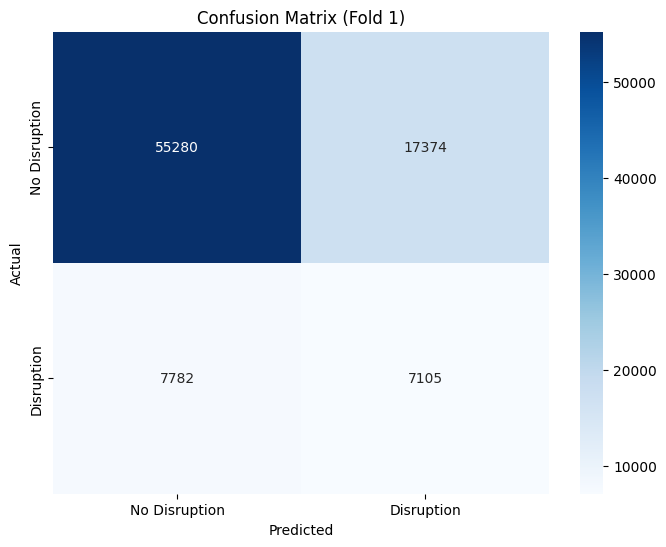


Fold 2/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7570/7570 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - AUC: 0.7554 - Precision: 0.6902 - Recall: 0.6902 - accuracy: 0.6902 - loss: 0.5872 - val_AUC: 0.6299 - val_Precision: 0.6018 - val_Recall: 0.6018 - val_accuracy: 0.6018 - val_loss: 0.6996
Epoch 2/50
7570/7570 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - AUC: 0.7977 - Precision: 0.7211 - Recall: 0.7211 - accuracy: 0.7211 - loss: 0.5436 - val_AUC: 0.5393 - val_Precision: 0.5340 - val_Recall: 0.5340 - val_accuracy: 0.5340 - val_loss: 0.8027
Epoch 3/50
7570/7570 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - AUC: 0.8117 - Precision: 0.7325 - Recall: 0.7325 - accuracy: 0.7325 - loss: 0.5266 - val_AUC: 0.6140 - val_Precision: 0.5710 - val_Recall: 0.5710 - val_accuracy: 0.5710 - val_loss: 0.7219
Epoch 4/50
7570/7570 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - AUC: 0.8192 - Precision: 0.7392 - Recall: 0.7392 - accuracy: 0.7392 - loss: 0.5177 - val_AUC: 0.5452 - val_Precision: 0.5568 - val_Recall: 0.5568 - val_accuracy: 0.5568 - val_loss: 0.8108
Epoch 5/50
7570/7570 ━━━━━━━━━━

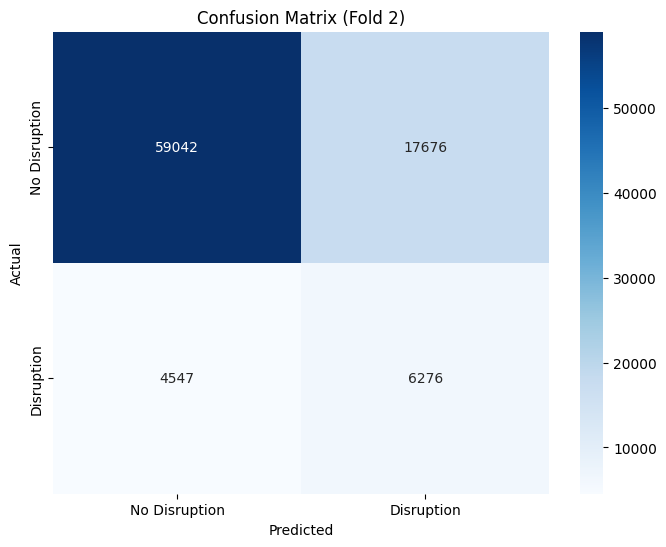


Fold 3/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11406/11406 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - AUC: 0.7632 - Precision: 0.6963 - Recall: 0.6963 - accuracy: 0.6963 - loss: 0.5802 - val_AUC: 0.4982 - val_Precision: 0.5098 - val_Recall: 0.5098 - val_accuracy: 0.5098 - val_loss: 0.8177
Epoch 2/50
11406/11406 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - AUC: 0.7990 - Precision: 0.7217 - Recall: 0.7217 - accuracy: 0.7217 - loss: 0.5422 - val_AUC: 0.4933 - val_Precision: 0.5021 - val_Recall: 0.5021 - val_accuracy: 0.5021 - val_loss: 0.8367
Epoch 3/50
11406/11406 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - AUC: 0.8100 - Precision: 0.7307 - Recall: 0.7307 - accuracy: 0.7307 - loss: 0.5294 - val_AUC: 0.5777 - val_Precision: 0.5605 - val_Recall: 0.5605 - val_accuracy: 0.5605 - val_loss: 0.7642
Epoch 4/50
11406/11406 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - AUC: 0.8170 - Precision: 0.7368 - Recall: 0.7368 - accuracy: 0.7368 - loss: 0.5214 - val_AUC: 0.5697 - val_Precision: 0.5777 - val_Recall: 0.5777 - val_accuracy: 0.5777 - val_loss: 0.7709
Epoch 5/50
11406/11406 

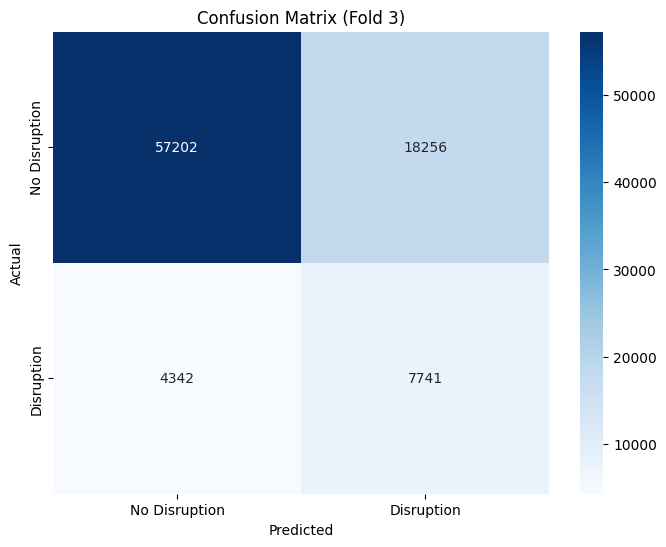


Fold 4/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15179/15179 ━━━━━━━━━━━━━━━━━━━━ 54s 3ms/step - AUC: 0.7751 - Precision: 0.7045 - Recall: 0.7045 - accuracy: 0.7045 - loss: 0.5686 - val_AUC: 0.6860 - val_Precision: 0.6583 - val_Recall: 0.6583 - val_accuracy: 0.6583 - val_loss: 0.6510
Epoch 2/50
15179/15179 ━━━━━━━━━━━━━━━━━━━━ 49s 3ms/step - AUC: 0.8034 - Precision: 0.7257 - Recall: 0.7257 - accuracy: 0.7257 - loss: 0.5378 - val_AUC: 0.5906 - val_Precision: 0.5715 - val_Recall: 0.5715 - val_accuracy: 0.5715 - val_loss: 0.7454
Epoch 3/50
15179/15179 ━━━━━━━━━━━━━━━━━━━━ 49s 3ms/step - AUC: 0.8118 - Precision: 0.7328 - Recall: 0.7328 - accuracy: 0.7328 - loss: 0.5275 - val_AUC: 0.5862 - val_Precision: 0.5672 - val_Recall: 0.5672 - val_accuracy: 0.5672 - val_loss: 0.7645
Epoch 4/50
15179/15179 ━━━━━━━━━━━━━━━━━━━━ 49s 3ms/step - AUC: 0.8182 - Precision: 0.7380 - Recall: 0.7380 - accuracy: 0.7380 - loss: 0.5198 - val_AUC: 0.6580 - val_Precision: 0.6345 - val_Recall: 0.6345 - val_accuracy: 0.6345 - val_loss: 0.6937
Epoch 5/50
15179/15179 

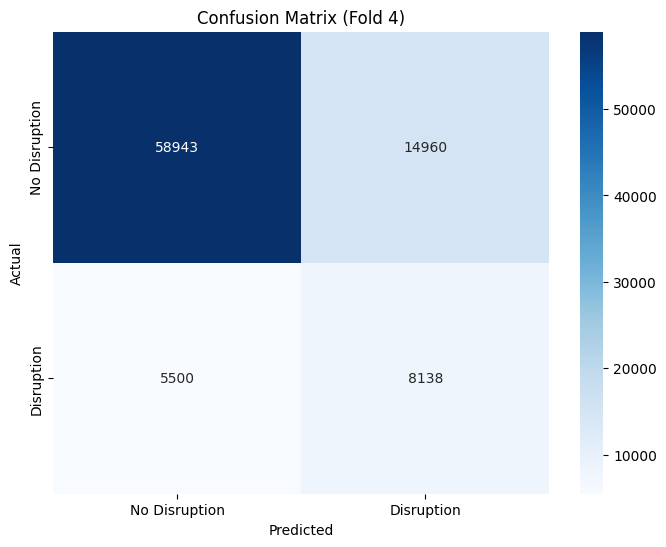


Fold 5/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18874/18874 ━━━━━━━━━━━━━━━━━━━━ 66s 3ms/step - AUC: 0.7795 - Precision: 0.7076 - Recall: 0.7076 - accuracy: 0.7076 - loss: 0.5644 - val_AUC: 0.5294 - val_Precision: 0.4971 - val_Recall: 0.4971 - val_accuracy: 0.4971 - val_loss: 0.7817
Epoch 2/50
18874/18874 ━━━━━━━━━━━━━━━━━━━━ 60s 3ms/step - AUC: 0.8052 - Precision: 0.7292 - Recall: 0.7292 - accuracy: 0.7292 - loss: 0.5366 - val_AUC: 0.6245 - val_Precision: 0.5776 - val_Recall: 0.5776 - val_accuracy: 0.5776 - val_loss: 0.7016
Epoch 3/50
18874/18874 ━━━━━━━━━━━━━━━━━━━━ 60s 3ms/step - AUC: 0.8152 - Precision: 0.7368 - Recall: 0.7368 - accuracy: 0.7368 - loss: 0.5248 - val_AUC: 0.6088 - val_Precision: 0.6054 - val_Recall: 0.6054 - val_accuracy: 0.6054 - val_loss: 0.7447
Epoch 4/50
18874/18874 ━━━━━━━━━━━━━━━━━━━━ 60s 3ms/step - AUC: 0.8210 - Precision: 0.7417 - Recall: 0.7417 - accuracy: 0.7417 - loss: 0.5176 - val_AUC: 0.5783 - val_Precision: 0.5664 - val_Recall: 0.5664 - val_accuracy: 0.5664 - val_loss: 0.7603
Epoch 5/50
18874/18874 

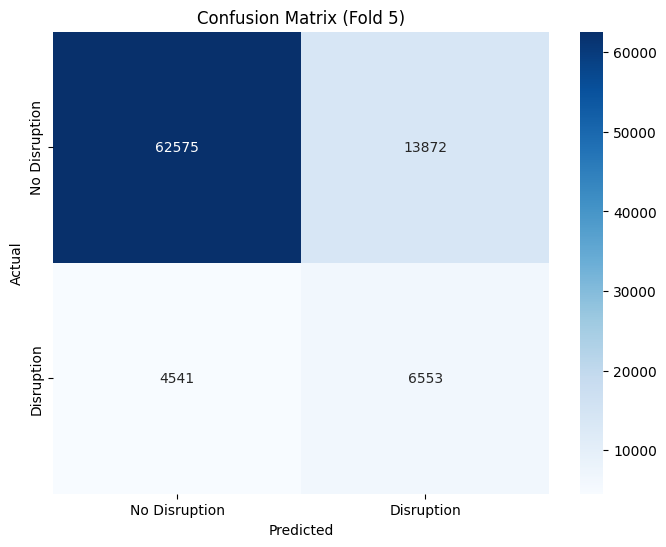


Fold 6/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22697/22697 ━━━━━━━━━━━━━━━━━━━━ 78s 3ms/step - AUC: 0.7848 - Precision: 0.7109 - Recall: 0.7109 - accuracy: 0.7109 - loss: 0.5586 - val_AUC: 0.6015 - val_Precision: 0.5863 - val_Recall: 0.5863 - val_accuracy: 0.5863 - val_loss: 0.7234
Epoch 2/50
22697/22697 ━━━━━━━━━━━━━━━━━━━━ 72s 3ms/step - AUC: 0.8086 - Precision: 0.7293 - Recall: 0.7293 - accuracy: 0.7293 - loss: 0.5318 - val_AUC: 0.5871 - val_Precision: 0.5734 - val_Recall: 0.5734 - val_accuracy: 0.5734 - val_loss: 0.7464
Epoch 3/50
22697/22697 ━━━━━━━━━━━━━━━━━━━━ 73s 3ms/step - AUC: 0.8182 - Precision: 0.7383 - Recall: 0.7383 - accuracy: 0.7383 - loss: 0.5208 - val_AUC: 0.6301 - val_Precision: 0.6149 - val_Recall: 0.6149 - val_accuracy: 0.6149 - val_loss: 0.7191
Epoch 4/50
22697/22697 ━━━━━━━━━━━━━━━━━━━━ 73s 3ms/step - AUC: 0.8258 - Precision: 0.7443 - Recall: 0.7443 - accuracy: 0.7443 - loss: 0.5112 - val_AUC: 0.5836 - val_Precision: 0.5563 - val_Recall: 0.5563 - val_accuracy: 0.5563 - val_loss: 0.7673
Epoch 5/50
22697/22697 

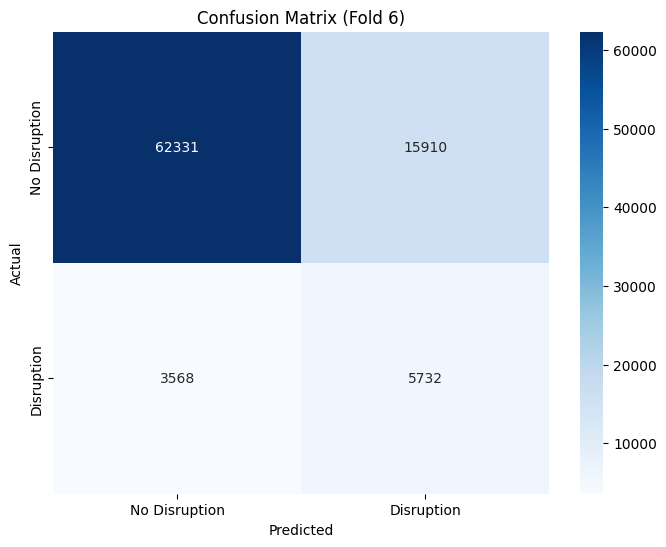


Cross-Validation Results (Mean ± Std):
Accuracy: 0.7557 ± 0.0254
Precision: 0.7557 ± 0.0254
Recall: 0.7557 ± 0.0254
F1: 0.3930 ± 0.0310
Auc: 0.7558 ± 0.0447
Balanced_acc: 0.6836 ± 0.0307


In [71]:
from sklearn.inspection import permutation_importance
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
X_topo_reshaped = X_topo.reshape((X_topo.shape[0], 1, X_topo.shape[1]))

def cross_validate_lstm(X, y, features, resample=False, n_splits=6, epochs=50, batch_size=32):
    scaler = StandardScaler()
    tss = TimeSeriesSplit(n_splits=n_splits)
    
    # Store metrics for each fold and model
    metrics = {
        'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'auc': [], 'balanced_acc': []
    }
    fold_results = []
    
    # Cross-validation loop
    for fold, (train_index, test_index) in enumerate(tss.split(X), 1):
        print(f"\nFold {fold}/{n_splits}")
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        # Apply SMOTE to training set if resample=True
        if resample:
            smote = SMOTE(random_state=42)
            X_train_reshaped = X_train.reshape(-1, X_train.shape[2])
            X_train_balanced, y_train_balanced = smote.fit_resample(X_train_reshaped, y_train)
            X_train = X_train_balanced.reshape(-1, X_train.shape[1], X_train.shape[2])
            y_train = y_train_balanced
        
        # Scale the features
        X_train_scaled = scaler.fit_transform(X_train.reshape(-1, X_train.shape[2])).reshape(X_train.shape)
        X_test_scaled = scaler.transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test.shape)
        
        # Convert labels to categorical
        y_train_categorical = to_categorical(y_train)
        y_test_categorical = to_categorical(y_test)
        
        # Build the LSTM model
        model = Sequential([
            LSTM(128, input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]), 
                 activation='relu', return_sequences=True),
            LSTM(64, activation='relu', return_sequences=False),
            Dense(32, activation='relu'),
            Dense(y_train_categorical.shape[1], activation='softmax')
        ])
        
        # Compile the model
        model.compile(optimizer='adam', 
                      loss='categorical_crossentropy', 
                      metrics=['accuracy', 'Precision', 'Recall', 'AUC'])
        
        # Train the model with early stopping
        early_stopping = EarlyStopping(monitor='val_Recall', patience=5, mode='max', restore_best_weights=True)
        history = model.fit(
            X_train_scaled, y_train_categorical,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.2,  # Uses last 20% of training data (time-ordered)
            callbacks=[early_stopping],
            verbose=1
        )
        
        # Evaluate the model on the test set
        loss, accuracy, precision, recall, auc = model.evaluate(X_test_scaled, y_test_categorical, verbose=0)
        y_pred_proba = model.predict(X_test_scaled)
        y_pred_classes = np.argmax(y_pred_proba, axis=1)
        y_test_classes = np.argmax(y_test_categorical, axis=1)
        
        # Calculate additional metrics
        f1 = f1_score(y_test_classes, y_pred_classes)
        balanced_acc = balanced_accuracy_score(y_test_classes, y_pred_classes)
        auc_roc = roc_auc_score(y_test_classes, y_pred_proba[:, 1])  # Use probabilities for AUC
        
        # Store metrics for this fold
        metrics['accuracy'].append(accuracy)
        metrics['precision'].append(precision)
        metrics['recall'].append(recall)
        metrics['f1'].append(f1)
        metrics['auc'].append(auc_roc)
        metrics['balanced_acc'].append(balanced_acc)
        
        # Print fold results
        print(f"Test Loss: {loss:.4f}")
        print(f"Test Accuracy: {accuracy:.4f}")
        print(f"Test Precision: {precision:.4f}")
        print(f"Test Recall: {recall:.4f}")
        print(f"Test F1 Score: {f1:.4f}")
        print(f"Test Balanced Accuracy: {balanced_acc:.4f}")
        print(f"Test AUC: {auc_roc:.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test_classes, y_pred_classes))
        cm = confusion_matrix(y_test_classes, y_pred_classes)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['No Disruption', 'Disruption'], 
                    yticklabels=['No Disruption', 'Disruption'])
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title(f'Confusion Matrix (Fold {fold})')
        plt.show()
        
        # Store fold results for later analysis
        fold_results.append({
            'fold': fold,
            'y_true': y_test_classes,
            'y_pred': y_pred_classes,
            'y_proba': y_pred_proba[:, 1]
        })
    
    # Aggregate and print cross-validation results
    print("\nCross-Validation Results (Mean ± Std):")
    results = {
        'accuracy': np.mean(metrics['accuracy']),
        'precision': np.mean(metrics['precision']),
        'recall': np.mean(metrics['recall']),
        'f1': np.mean(metrics['f1']),
        'auc': np.mean(metrics['auc']),
        'balanced_acc': np.mean(metrics['balanced_acc'])
    }
    for metric in metrics:
        mean = np.mean(metrics[metric])
        std = np.std(metrics[metric])
        print(f"{metric.capitalize()}: {mean:.4f} ± {std:.4f}")
    return model, metrics, results


# Example usage
# Assuming X_topo_reshaped, y, feature_df are defined
features = feature_df.drop(columns=['Disrupted']).columns.tolist()
final_model, cv_metrics, feature_importance = cross_validate_lstm(
    X=X_topo_reshaped, 
    y=y, 
    features=features, 
    resample=True, 
    n_splits=6, 
    epochs=50, 
    batch_size=32
)